In [2]:
import specpolFlow as pol
import matplotlib.pyplot as plt
import VPtools as vp
import numpy as np
from pathlib import Path
import math
from matplotlib.gridspec import GridSpec


path_google = 'G:/Shared drives/'
obs_folder = Path(r"G:\Shared drives\BinamicsOstars\DataFromEve\spectra_tovero")
save_folder = Path(r"G:\Shared drives\BinamicsOstars\TLUSTY Fitting Diagnostic Plots")
# helper functions
def make_binary_model_O(p):
    file1 = f"G{p['teff1']}g{p['logg1']}v{p['vturb']}.vis"
    file2 = f"G{p['teff2']}g{p['logg2']}v{p['vturb']}.vis"

    model_name1 = vp.tlusty.galO_path_name.format(
        "vis", p["teff1"], p["logg1"], p["vturb"]
    )
    model_name2 = vp.tlusty.galO_path_name.format(
        "vis", p["teff2"], p["logg2"], p["vturb"]
    )

    model = vp.tlusty_binary(
        path_google,
        model_name1,
        model_name2,
        p["vsini1"],
        p["vsini2"],
        p["R2R1"],
        p["vrad1"],
        p["vrad2"]
    )

    label = (
        f"{file1}+{file2}\n"
        f"vrad=({p['vrad1']},{p['vrad2']}), "
        f"vsini=({p['vsini1']},{p['vsini2']}), "
        f"R2/R1={p['R2R1']}"
    )

    return model, label
def make_binary_model_B(p): # B star
    file1 = f"G{p['teff1']}g{p['logg1']}v{p['vturb']}.vis"
    file2 = f"G{p['teff2']}g{p['logg2']}v{p['vturb']}.vis"

    model_name1 = vp.tlusty.galB_path_name.format(
        "vis", p["teff1"], p["logg1"], p["vturb"]
    )
    model_name2 = vp.tlusty.galB_path_name.format(
        "vis", p["teff2"], p["logg2"], p["vturb"]
    )

    model = vp.tlusty_binary(
        path_google,
        model_name1,
        model_name2,
        p["vsini1"],
        p["vsini2"],
        p["R2R1"],
        p["vrad1"],
        p["vrad2"]
    )

    label = (
        f"{file1}+{file2}\n"
        f"vrad=({p['vrad1']},{p['vrad2']}), "
        f"vsini=({p['vsini1']},{p['vsini2']}), "
        f"R2/R1={p['R2R1']}"
    )

    return model, label
def make_binary_model_OB(p): # OB pair
    file1 = f"G{p['teff1']}g{p['logg1']}v{p['vturb']}.vis"
    file2 = f"G{p['teff2']}g{p['logg2']}v{p['vturb']}.vis"

    model_name1 = vp.tlusty.galO_path_name.format(
        "vis", p["teff1"], p["logg1"], p["vturb"]
    )
    model_name2 = vp.tlusty.galB_path_name.format(
        "vis", p["teff2"], p["logg2"], p["vturb"]
    )

    model = vp.tlusty_binary(
        path_google,
        model_name1,
        model_name2,
        p["vsini1"],
        p["vsini2"],
        p["R2R1"],
        p["vrad1"],
        p["vrad2"]
    )

    label = (
        f"{file1}+{file2}\n"
        f"vrad=({p['vrad1']},{p['vrad2']}), "
        f"vsini=({p['vsini1']},{p['vsini2']}), "
        f"R2/R1={p['R2R1']}"
    )

    return model, label
def dopplershift_rotate(spectrum, dopplershift, vsini):
    """Apply radial-velocity shift followed by rotational broadening."""
    shifted_spectrum = spectrum.doppler_shift(dopplershift)
    broadened_spectrum = shifted_spectrum.convolveRot(vsini, 0.5)
    return broadened_spectrum
def make_single_model(params):

    grid = params["grid"].upper()

    if grid == "B":
        path_template = vp.tlusty.galB_path_name
    elif grid == "O":
        path_template = vp.tlusty.galO_path_name
    else:
        raise ValueError(
            f"Unknown grid {params['grid']!r}. "
            "Expected 'B' or 'O'."
        )

    model_path = path_template.format(
        "vis",
        params["teff"],
        params["logg"],
        str(params["vturb"]),
    )

    full_model_path = path_google + model_path

    model = vp.tlusty.read_norm(full_model_path)

    model = dopplershift_rotate(
        spectrum=model,
        dopplershift=params["vrad"],
        vsini=params["vsini"],
    )

    return model
def make_binary_components(params):
    """
    Generate the two stellar contributions to the normalized binary spectrum
    based on star_1 = F1/(C1+C2(R2R1**2)) and star_2 = F2 * R2R1**2/(C1+C2(R2R1**2)).
    """


    if params["grid_1"].upper() == "B":
        path_template_1 = vp.tlusty.galB_path_name
    elif params["grid_1"].upper() == "O":
        path_template_1 = vp.tlusty.galO_path_name
    else:
        raise ValueError("grid_1 must be 'B' or 'O'")

    if params["grid_2"].upper() == "B":
        path_template_2 = vp.tlusty.galB_path_name
    elif params["grid_2"].upper() == "O":
        path_template_2 = vp.tlusty.galO_path_name
    else:
        raise ValueError("grid_2 must be 'B' or 'O'")

    vturb1 = params.get("vturb1", params["vturb"])
    vturb2 = params.get("vturb2", params["vturb"])

    model_path_1 = path_template_1.format("vis",params["teff1"],params["logg1"],str(vturb1))
    model_path_2 = path_template_2.format("vis",params["teff2"],params["logg2"],str(vturb2))

    synth1, synth1_con = vp.tlusty.read(path_google + model_path_1) 
    synth2, synth2_con = vp.tlusty.read(path_google + model_path_2)

    wl = synth1.wl

    # Star 1
    shifted1 = synth1.doppler_shift(params["vrad1"])
    shifted1_con = synth1_con.doppler_shift(params["vrad1"])

    interp1 = shifted1.interp(wl) 
    interp1_con = shifted1_con.interp(wl)

    broad1 = interp1.rot_int_cmj(vsini=params["vsini1"])

    broad1_con = interp1_con.rot_int_cmj(vsini=params["vsini1"])


    # Star 2
    shifted2 = synth2.doppler_shift(params["vrad2"])
    shifted2_con = synth2_con.doppler_shift(params["vrad2"])

    interp2 = shifted2.interp(wl)
    interp2_con = shifted2_con.interp(wl)

    broad2 = interp2.rot_int_cmj(
        vsini=params["vsini2"]
    )

    broad2_con = interp2_con.rot_int_cmj(
        vsini=params["vsini2"]
    )

    R2R1 = params["R2R1"]

    total_continuum = (broad1_con.specI+ broad2_con.specI * R2R1**2) # denominator

    contribution_1 = (broad1.specI / total_continuum)

    contribution_2 = (broad2.specI * R2R1**2 / total_continuum)


    continuum_1 = (broad1_con.specI/ total_continuum)

    continuum_2 = (broad2_con.specI * R2R1**2/total_continuum)

    contribution_1_shifted = (contribution_1+ (1 - continuum_1))

    contribution_2_shifted = (contribution_2+ (1 -continuum_2)  )
    
    component_1 = vp.synth.Synth(wl,contribution_1_shifted)

    component_2 = vp.synth.Synth(wl, contribution_2_shifted)



    label_1 = (
        rf"Component 1 ({params['grid_1']}-grid): "
        rf"$T_{{\rm eff}}={params['teff1']}$ K, "
        rf"$\log g={params['logg1'] / 100:.2f}$, "
        rf"$v\sin i={params['vsini1']}$ km s$^{{-1}}$, "
        rf"$v_r={params['vrad1']}$ km s$^{{-1}}$"
    )

    label_2 = (
        rf"Component 2 ({params['grid_2']}-grid): "
        rf"$T_{{\rm eff}}={params['teff2']}$ K, "
        rf"$\log g={params['logg2'] / 100:.2f}$, "
        rf"$v\sin i={params['vsini2']}$ km s$^{{-1}}$, "
        rf"$v_r={params['vrad2']}$ km s$^{{-1}}$"
    )

    return component_1, component_2, label_1, label_2


In [3]:
# spectrum
hd = "hd23625"    

obs = sorted([f.name for f in obs_folder.glob(f"{hd}*.s")])

print(f"Found {len(obs)} observations for {hd}:")
for f in obs:
    print(f)

filename1 = obs[0]
filename2 = obs[1]
spec1 = pol.read_spectrum(obs_folder / filename1)
spec1 = spec1.merge_orders(mode="trim")
label1 = filename1.replace("_rn.s", "")

spec2 = pol.read_spectrum(obs_folder / filename2)
spec2 = spec2.merge_orders(mode="trim")
label2 = filename2.replace("_rn.s", "")

filename3 = obs[2]

spec3 = pol.read_spectrum(obs_folder/filename3)
spec3 = spec3.merge_orders(mode="trim")
label3 = filename3.replace("_rn.s","")


Found 3 observations for hd23625:
hd23625_2004924pnm_rn.s
hd23625_E_1650068pnm_rn.s
hd23625_E_2004924pnm_rn.s


In [4]:
spec = spec1
observation_name = filename1
print(f"Inspecting: {observation_name}")

Inspecting: hd23625_2004924pnm_rn.s


In [5]:
# model

params_B = {
    "grid_1":"B", "grid_2":"B",
    "teff1": 18000, "logg1":400,
    "teff2": 17000, "logg2":350,
    "vsini1": 50, "vsini2": 50,
    "vrad1": -100, "vrad2": 100,
    "R2R1":1.3,
    "vturb": 2,


}


component_1, component_2, label_1, label_2 = (make_binary_components(params_B))
model, model_label = make_binary_model_B(params_B)
components = [
    (component_1, label_1),
    (component_2, label_2),
]
windows = [(400, 412),(432, 440),(445, 455),(467, 473),(485, 495)]

lines_H = [(410.1, "Hδ 4101"),(434.0, "Hγ 4340"),(486.1, "Hβ 4861")]

lines_He = [
    (402.6, "He I/II 4026"),
    (420.0, "He II 4200"),
    (438.7, "He I 4387"),
    (447.1, "He I 4471"),
    (448.1, "Mg II 4481"),
    (454.1, "He II 4541"),
    (468.6, "He II 4686"),
    (471.3, "He I 4713"),
    (492.2, "He I 4922"),
    (501.6, "He I 5016"),
    (580.1, "C IV 5801"),
    (581.1, "C IV 5811"),]


In [6]:
notes = (
    f"Object: {hd}\n"
    f"This object has a total of 2 observations: {filename1} and {filename2}. Here we provide a section of the spectra from roughly 400 nm to 500 nm.\n"
    f"Notes: The spectra show radial velocity shift clearly in He lines, such as He I 4387 and He I 4471. This variation is less obvious in the Balmer series.\n"
    f"The He lines have a shift in its wing. This object is more likely to be a binary system rather than a pulsating star.\n"
    f"For {filename1}, we provide a TLUSTY binary model fitting with two B stars on RHS panels, parameters listed below.\n"
    f"$T_{{\\rm eff,1}}$ = {params_B['teff1']} K, $\\log g_1$ = {params_B['logg1']/100:.2f}, "
    f"$v\\sin i_1$ = {params_B['vsini1']} km/s, $v_{{\\rm rad,1}}$ = {params_B['vrad1']} km/s\n"
    f"$T_{{\\rm eff,2}}$ = {params_B['teff2']} K, $\\log g_2$ = {params_B['logg2']/100:.2f}, "
    f"$v\\sin i_2$ = {params_B['vsini2']} km/s, $v_{{\\rm rad,2}}$ = {params_B['vrad2']} km/s\n"
    f"$R_2/R_1$ = {params_B['R2R1']}\n"

)



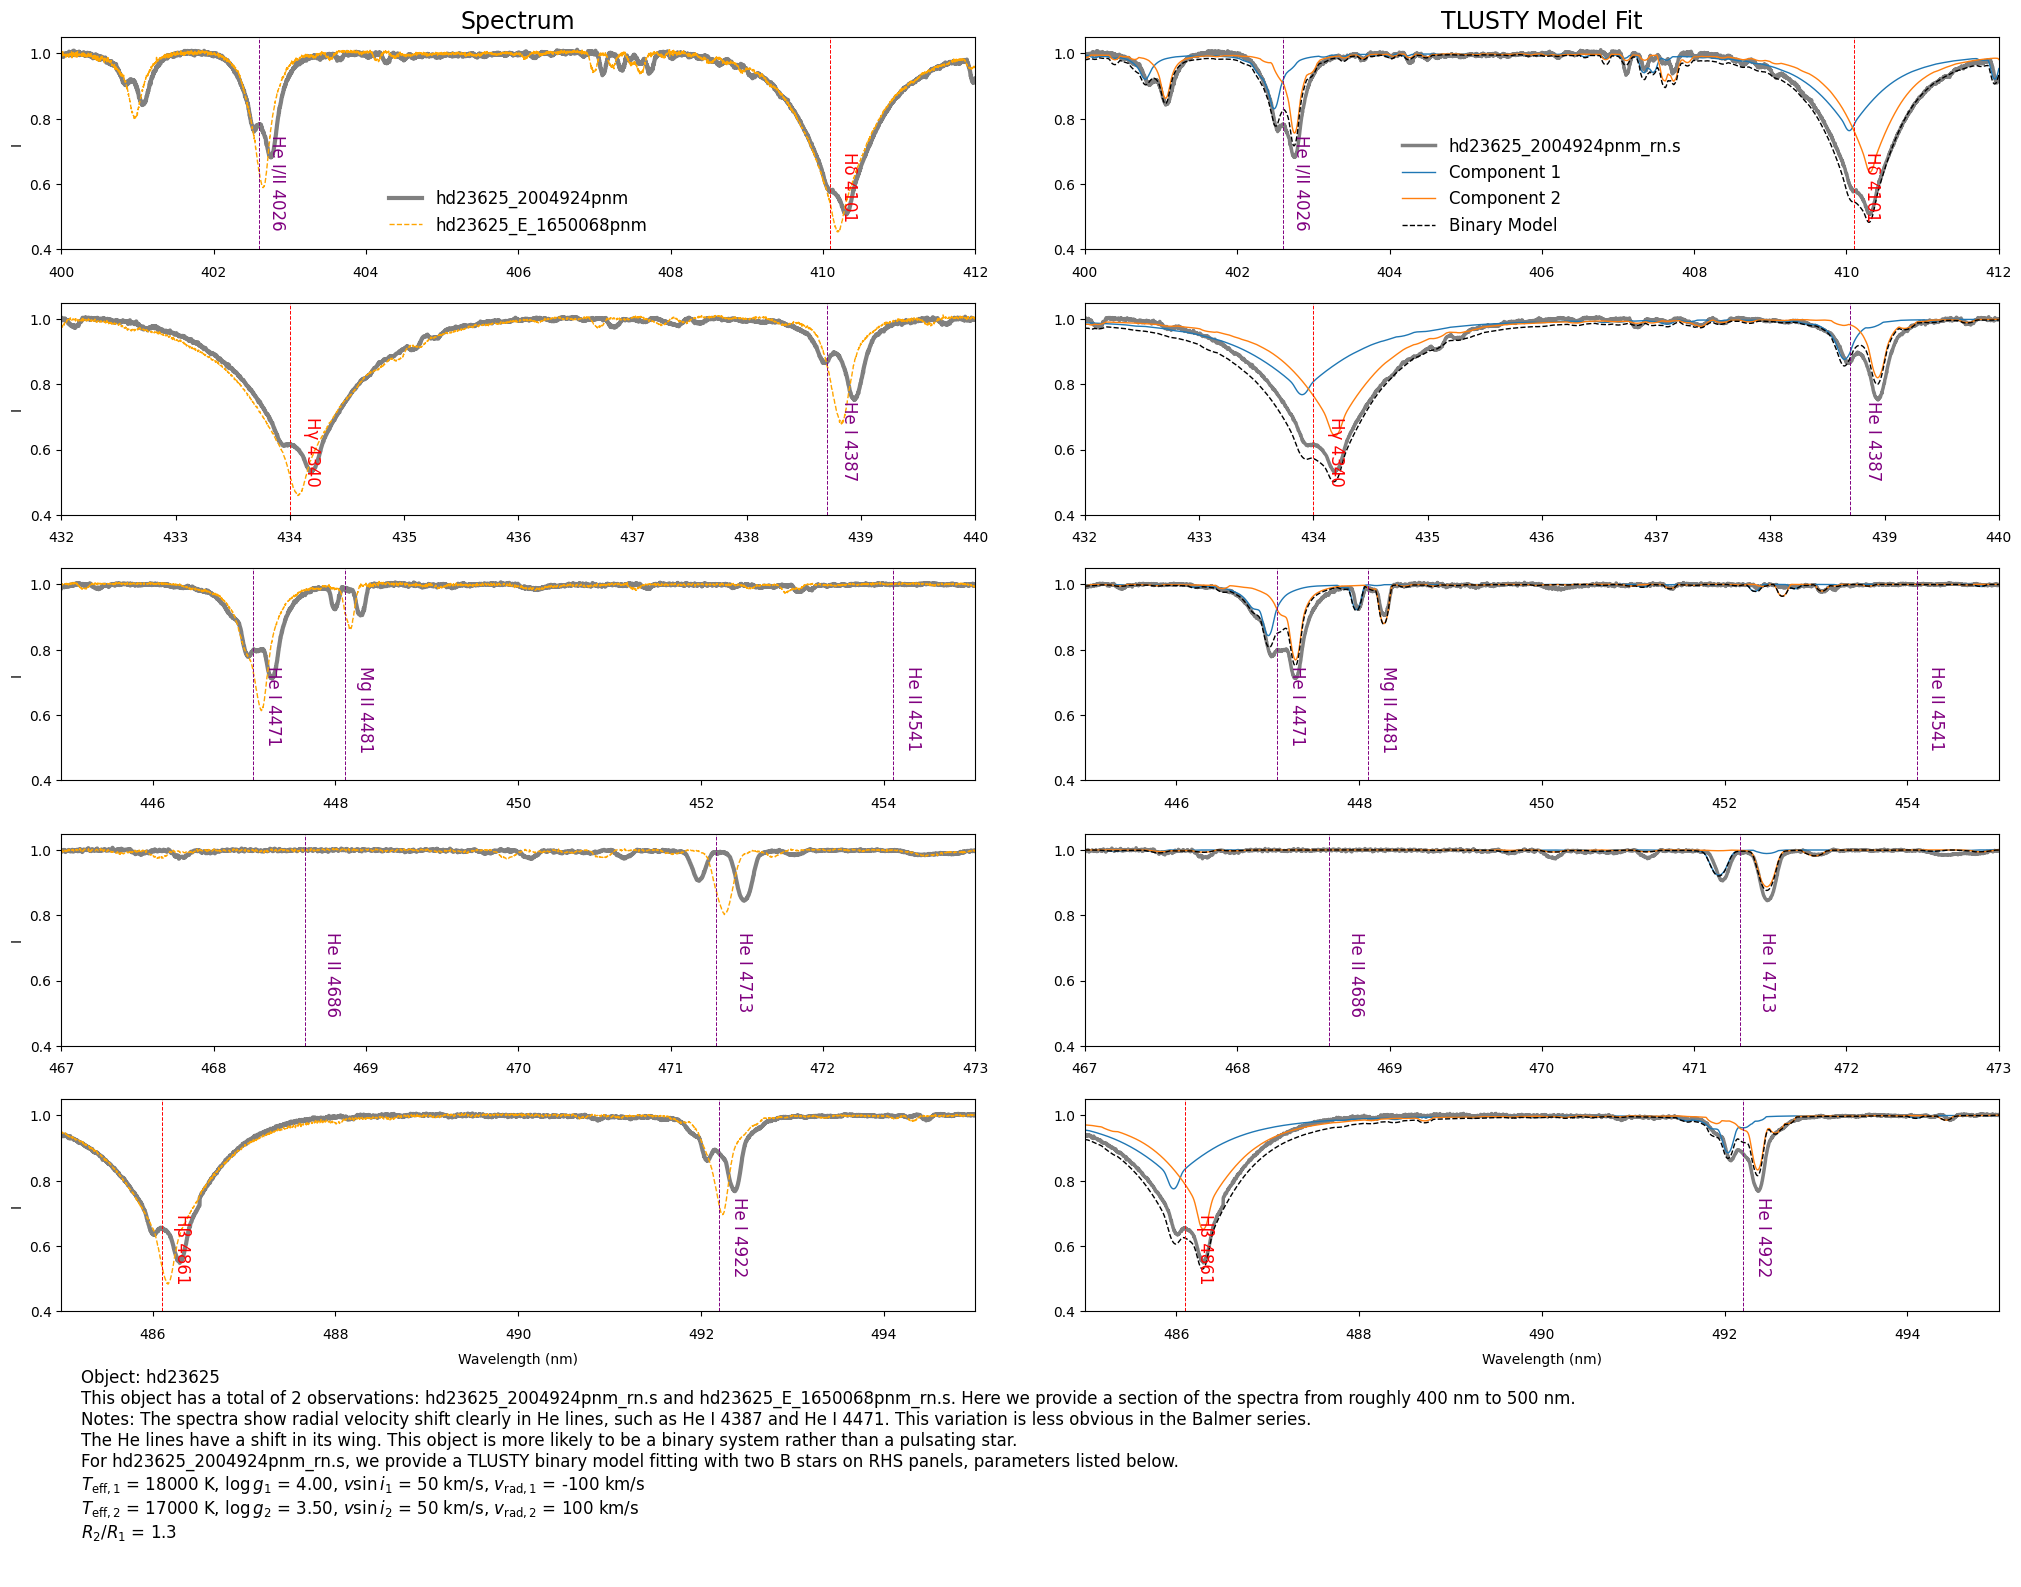

In [7]:
# side by side plot

y_lim = 0.4

fig = plt.figure(figsize=(25, 20))

gs = GridSpec(6, 2, figure=fig,
              height_ratios=[1,1,1,1,1,1],
              hspace=0.25, wspace=0.12)

ax_obs = [fig.add_subplot(gs[i, 0]) for i in range(5)]
ax_model = [fig.add_subplot(gs[i, 1]) for i in range(5)]
ax_text = fig.add_subplot(gs[5, :])
plt.rcParams.update({
    "font.size": 14,
    "axes.titlesize": 17,
    "axes.labelsize": 15,
    "xtick.labelsize": 13,
    "ytick.labelsize": 13,
    "legend.fontsize": 12})

for i, (xmin, xmax) in enumerate(windows):
    a = ax_obs[i]

    a.plot(spec1.wl, spec1.specI, lw=3, color="grey", label=label1)
    a.plot(spec2.wl, spec2.specI, lw=1, color="orange", ls='--', label=label2)
    # a.plot(spec3.wl, spec3.specI, lw=1, color="cyan", ls='--', label=label3)

    a.set_xlim(xmin, xmax)
    a.set_ylim(y_lim, 1.05)
    a.set_ylabel("I")
    a.tick_params(axis="x", pad=8)

    for wl, label in lines_H:
        if xmin <= wl <= xmax:
            a.axvline(wl, color="red", ls="--", lw=0.7)
            a.text(wl+0.12, 0.7, label, color="red", fontsize=12,
                   rotation=-90, ha="left", va="top")

    for wl, label in lines_He:
        if xmin <= wl <= xmax:
            a.axvline(wl, color="purple", ls="--", lw=0.7)
            a.text(wl+0.12, 0.75, label, color="purple", fontsize=12,
                   rotation=-90, ha="left", va="top")

ax_obs[0].legend(loc="lower center", frameon=False)
ax_obs[0].set_title("Spectrum")
ax_obs[-1].set_xlabel("Wavelength (nm)", labelpad=8)

# =========================
# TLUSTY model fit
# =========================

for i, (xmin, xmax) in enumerate(windows):
    a = ax_model[i]

    a.plot(spec.wl, spec.specI, color="grey", lw=2.5, label=observation_name)

    for j, (component, label) in enumerate(components):
        a.plot(component.wl/10, component.specI, lw=1, label=f"Component {j+1}")

    a.plot(model.wl/10, model.specI, lw=1, color="black", ls="--", label="Binary Model")

    a.set_xlim(xmin, xmax)
    a.set_ylim(y_lim, 1.05)
    a.tick_params(axis="x", pad=8)

    for wl, label in lines_H:
        if xmin <= wl <= xmax:
            a.axvline(wl, color="red", ls="--", lw=0.7)
            a.text(wl+0.12, 0.7, label, color="red", fontsize=12,
                   rotation=-90, ha="left", va="top")

    for wl, label in lines_He:
        if xmin <= wl <= xmax:
            a.axvline(wl, color="purple", ls="--", lw=0.7)
            a.text(wl+0.12, 0.75, label, color="purple", fontsize=12,
                   rotation=-90, ha="left", va="top")

ax_model[0].legend(loc="lower center", frameon=False)
ax_model[0].set_title("TLUSTY Model Fit")
ax_model[-1].set_xlabel("Wavelength (nm)", labelpad=8)

ax_text.axis("off")
object_name = observation_name.split("_")[0]

ax_text.text(0.01, 0.98, notes, va="top", fontsize=12,wrap=True)

plt.savefig(save_folder / f"{observation_name.replace('_rn.s', '')}_diagnostics.pdf",dpi=300,
    bbox_inches="tight",pad_inches=0.3
)

plt.show()

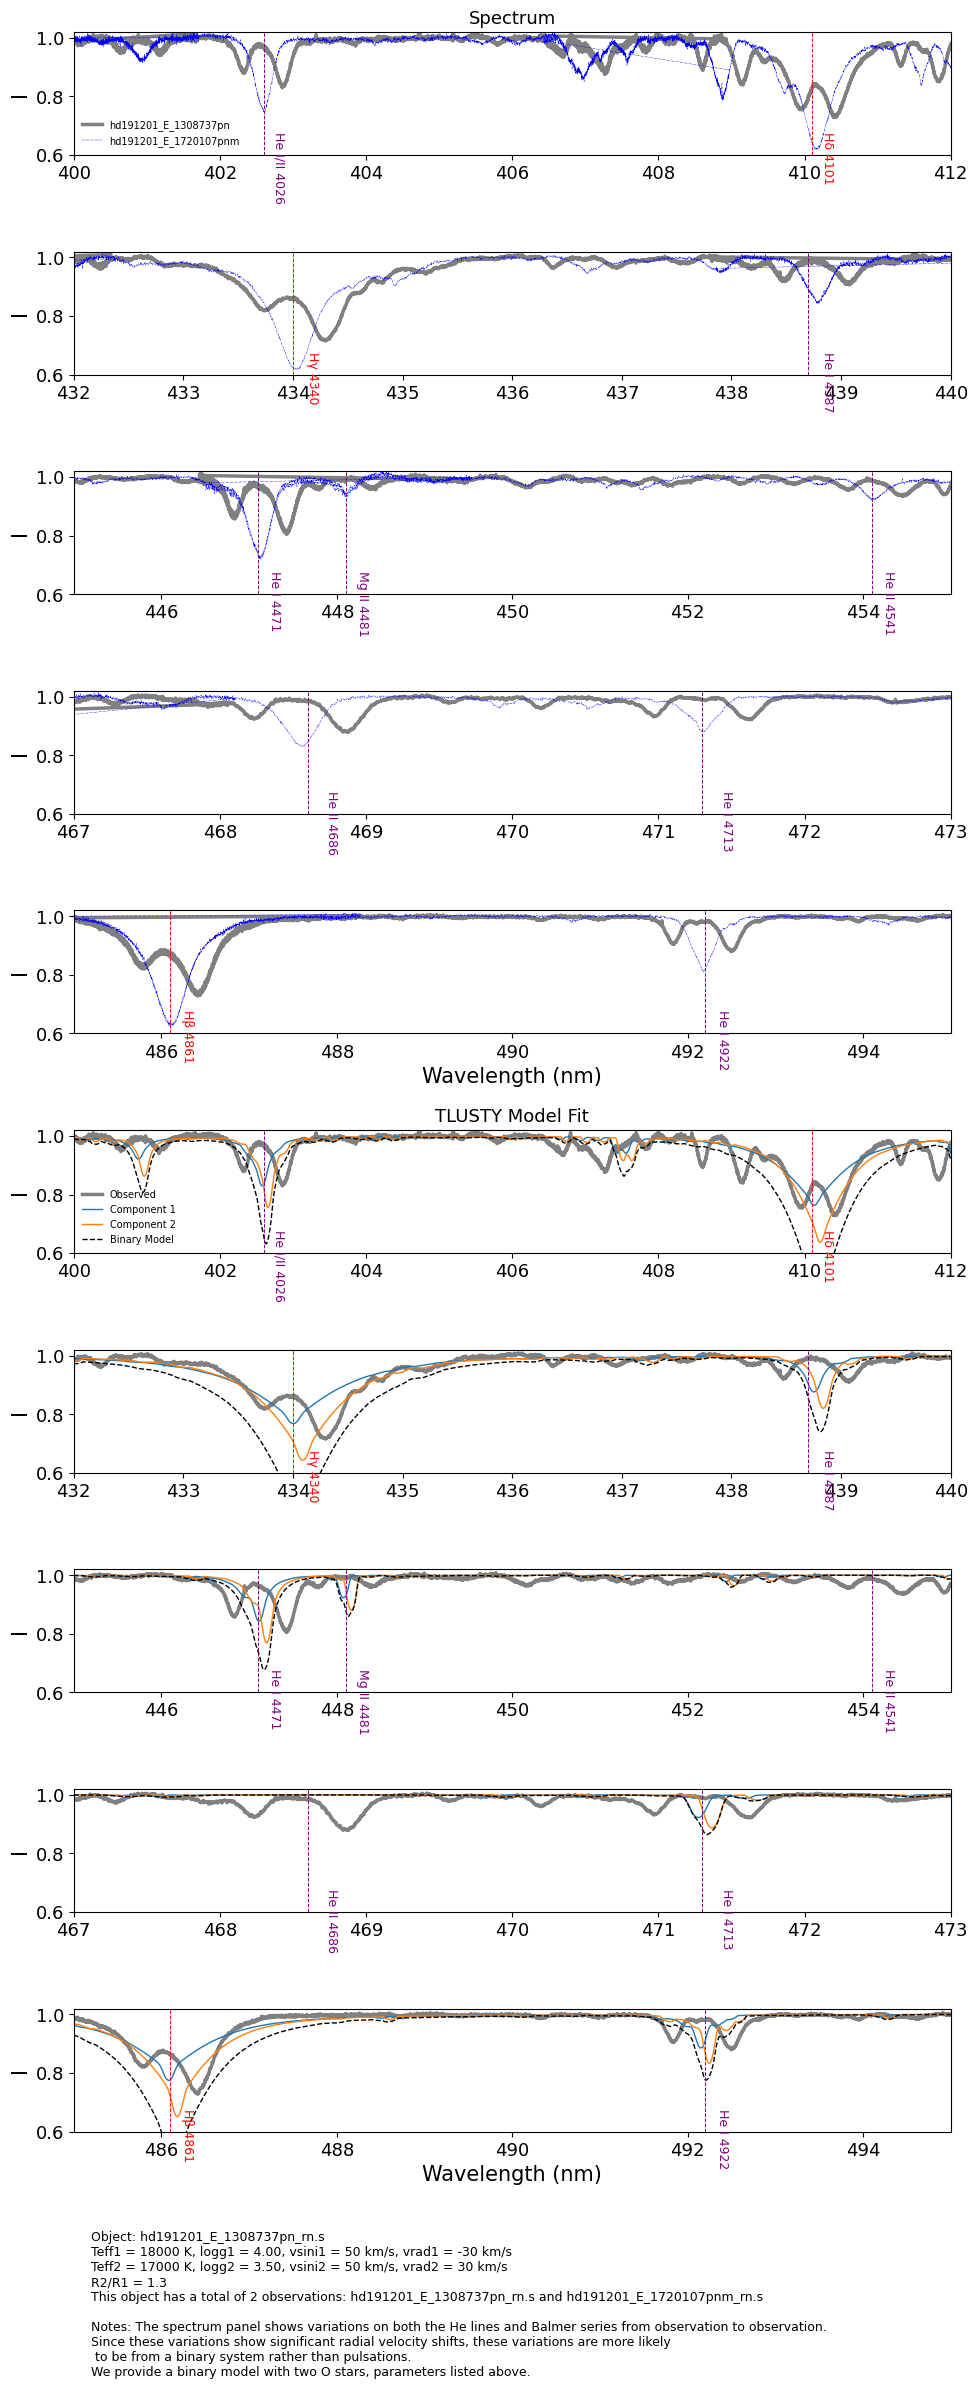

In [ ]:
# long pdf
from matplotlib.gridspec import GridSpec

filename1 = "hd191201_E_1308737pn_rn.s"
filename2 = "hd191201_E_1720107pnm_rn.s"

spec1 = pol.read_spectrum(obs_folder / filename1)
spec2 = pol.read_spectrum(obs_folder / filename2)

label1 = filename1.replace("_rn.s", "")
label2 = filename2.replace("_rn.s", "")

fig = plt.figure(figsize=(10, 24))
gs = GridSpec(
    11, 1,
    figure=fig,
    height_ratios=[1,1,1,1,1, 1,1,1,1,1, 0.45]
)

ax_obs = [fig.add_subplot(gs[i]) for i in range(5)]
ax_model = [fig.add_subplot(gs[i+5]) for i in range(5)]
ax_text = fig.add_subplot(gs[10])


# =========================
# Spectrum comparison
# =========================

for i, (xmin, xmax) in enumerate(windows):
    a = ax_obs[i]

    a.plot(spec1.wl, spec1.specI, lw=2.5, color="grey", label=label1)
    a.plot(spec2.wl, spec2.specI, lw=0.3, color="blue", ls="-.", label=label2)

    a.set_xlim(xmin, xmax)
    a.set_ylim(0.6, 1.02)
    a.set_ylabel("I")

    for wl, label in lines_H:
        if xmin <= wl <= xmax:
            a.axvline(wl, color="red", ls="--", lw=0.7)
            a.text(wl+0.12, 0.68, label, color="red", fontsize=9,
                   rotation=-90, ha="left", va="top")

    for wl, label in lines_He:
        if xmin <= wl <= xmax:
            a.axvline(wl, color="purple", ls="--", lw=0.7)
            a.text(wl+0.12, 0.68, label, color="purple", fontsize=9,
                   rotation=-90, ha="left", va="top")

ax_obs[0].legend(loc="lower left", fontsize=7, frameon=False)
ax_obs[0].set_title("Spectrum", fontsize=13)
ax_obs[-1].set_xlabel("Wavelength (nm)")


# =========================
# TLUSTY model fit
# =========================

for i, (xmin, xmax) in enumerate(windows):
    a = ax_model[i]

    a.plot(spec.wl, spec.specI, color="grey", lw=2.5, label="Observed")

    for j, (component, label) in enumerate(components):
        a.plot(component.wl/10, component.specI, lw=1,
               label=f"Component {j+1}")

    a.plot(model.wl/10, model.specI, lw=1,
           color="black", ls="--", label="Binary Model")

    a.set_xlim(xmin, xmax)
    a.set_ylim(0.6, 1.02)
    a.set_ylabel("I")

    for wl, label in lines_H:
        if xmin <= wl <= xmax:
            a.axvline(wl, color="red", ls="--", lw=0.7)
            a.text(wl+0.12, 0.68, label, color="red", fontsize=9,
                   rotation=-90, ha="left", va="top")

    for wl, label in lines_He:
        if xmin <= wl <= xmax:
            a.axvline(wl, color="purple", ls="--", lw=0.7)
            a.text(wl+0.12, 0.68, label, color="purple", fontsize=9,
                   rotation=-90, ha="left", va="top")

ax_model[0].legend(loc="lower left", fontsize=7, frameon=False)
ax_model[0].set_title("TLUSTY Model Fit", fontsize=13)
ax_model[-1].set_xlabel("Wavelength (nm)")


# =========================
# Notes
# =========================

ax_text.axis("off")

notes = (
    f"Object: {observation_name}\n"
    f"Teff1 = {params_B['teff1']} K, logg1 = {params_B['logg1']/100:.2f}, "
    f"vsini1 = {params_B['vsini1']} km/s, vrad1 = {params_B['vrad1']} km/s\n"
    f"Teff2 = {params_B['teff2']} K, logg2 = {params_B['logg2']/100:.2f}, "
    f"vsini2 = {params_B['vsini2']} km/s, vrad2 = {params_B['vrad2']} km/s\n"
    f"R2/R1 = {params_B['R2R1']}\n"
    f"This object has a total of 2 observations: {filename1} and {filename2}\n"
    f"\nNotes: The spectrum panel shows variations on both the He lines and Balmer series from observation to observation.\n"
    f"Since these variations show significant radial velocity shifts, these variations are more likely\n "
    f"to be from a binary system rather than pulsations.\n"
    f"We provide a binary model with two O stars, parameters listed above."
)

ax_text.text(0.02, 0.95, notes, va="top", fontsize=9)

fig.tight_layout()

plt.savefig(
    f"{observation_name.replace('_rn.s', '')}_diagnostics.pdf",
    dpi=300,
    bbox_inches="tight"
)

plt.show()